<a href="https://colab.research.google.com/github/SoumitraDas1/QuantumKAN/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task I

## 1. A simple quantum operation with Pennylane

In [1]:
!pip install pennylane

In [2]:
import pennylane as qml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

 ***Device: 5 qubits***

In [3]:
dev = qml.device("default.qubit", wires=5)

In [4]:
@qml.qnode(dev)
def quantum_circuit():
    # (b) Hadamard on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)

    # (c) CNOT chain: (0→1), (1→2), (2→3), (3→4)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 4])

    # (d) SWAP qubits 0 and 4
    qml.SWAP(wires=[0, 4])

    # (e) Rotate-X by π/2 on qubit 2  (arbitrary choice)
    qml.RX(np.pi / 2, wires=2)

    return qml.state()

Final state vector (first 8 amplitudes shown):
  |00000⟩  0.125000-0.125000j
  |00001⟩  0.125000-0.125000j
  |00010⟩  0.125000-0.125000j
  |00011⟩  0.125000-0.125000j
  |00100⟩  0.125000-0.125000j
  |00101⟩  0.125000-0.125000j
  |00110⟩  0.125000-0.125000j
  |00111⟩  0.125000-0.125000j
  ...


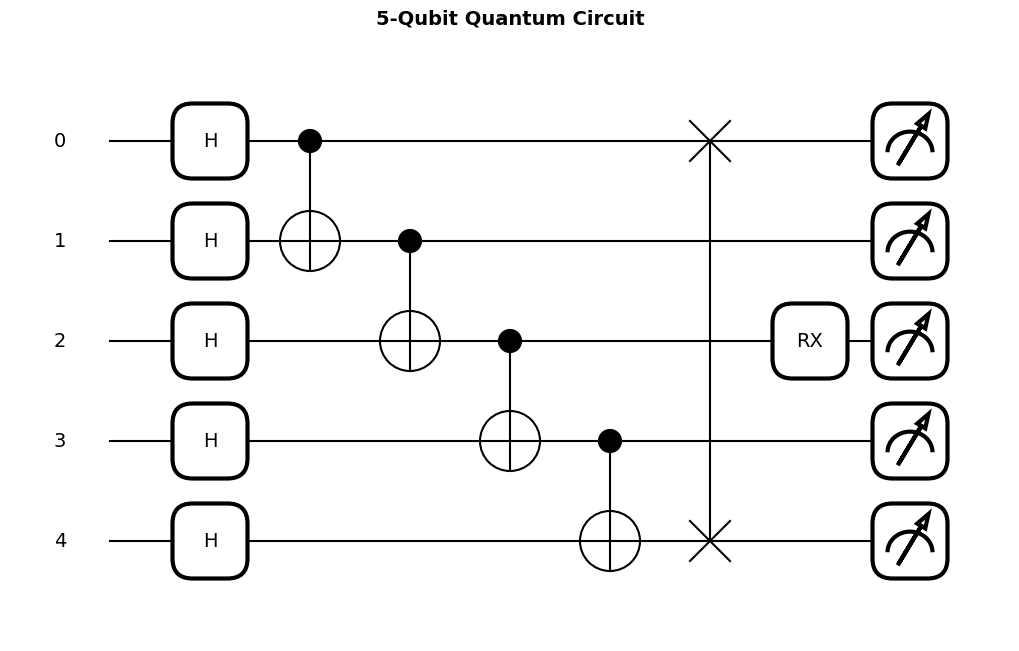

In [5]:
# ── Run & print state vector ───────────────────────────────────────────────────
state = quantum_circuit()
print("Final state vector (first 8 amplitudes shown):")
for idx, amp in enumerate(state[:8]):
    print(f"  |{idx:05b}⟩  {amp:.6f}")
print("  ...")

# Draw AFTER the circuit has been executed
fig, ax = qml.draw_mpl(quantum_circuit)()
ax.set_title("5-Qubit Quantum Circuit", fontsize=14, fontweight="bold", pad=12)
plt.show()

## 2. Another Quantum Circuit

SWAP Test Circuit

 Wire layout:

 ancilla  : wire 0         (SWAP test ancilla qubit)

 state A  : wires 1, 2    (q1=Hadamard, q2=RX(π/3))

 state B  : wires 3, 4    (q3=Hadamard, q4=Hadamard)

         SWAP Test Results
  P(ancilla = |0⟩) : 0.750000
  P(ancilla = |1⟩) : 0.250000
  |⟨ψ|φ⟩|²         : 0.500000
  |⟨ψ|φ⟩|  (fidelity): 0.707107
  → States are PARTIALLY OVERLAPPING


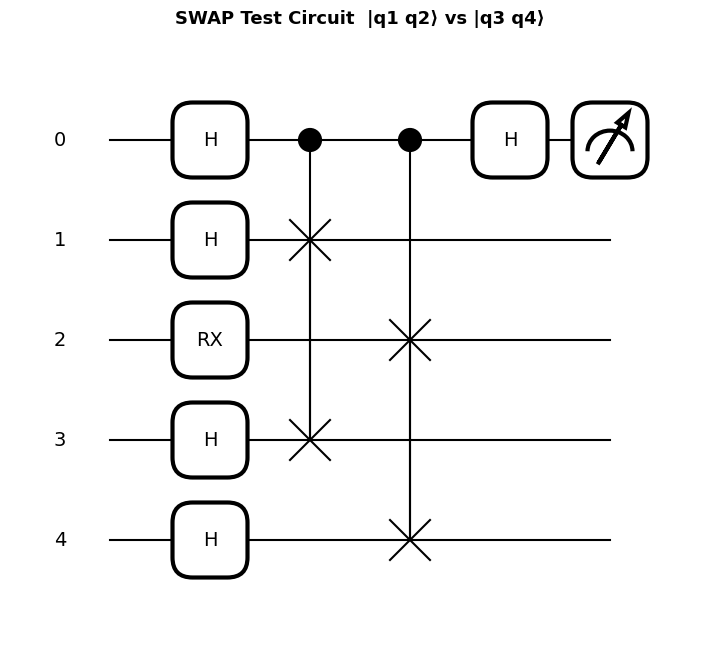

In [6]:
dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def swap_test_circuit():

    # -- Prepare |ψ⟩ = |q1 q2⟩ on wires 1, 2 --
    # 1. Hadamard on first qubit (wire 1)
    qml.Hadamard(wires=1)

    # 2. Rotate second qubit by π/3 around X (wire 2)
    qml.RX(np.pi / 3, wires=2)

    # -- Prepare |φ⟩ = |q3 q4⟩ on wires 3, 4 --
    # 3. Hadamard on third and fourth qubit (wires 3, 4)
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=4)

    # -- SWAP Test --
    # Step 1: Hadamard on ancilla (wire 0)
    qml.Hadamard(wires=0)

    # Step 2: Controlled-SWAP (Fredkin) between state A and state B
    #         ancilla (wire 0) controls SWAP of (wire 1 ↔ wire 3) and (wire 2 ↔ wire 4)
    qml.CSWAP(wires=[0, 1, 3])   # controlled-SWAP q1 ↔ q3
    qml.CSWAP(wires=[0, 2, 4])   # controlled-SWAP q2 ↔ q4

    # Step 3: Hadamard on ancilla again
    qml.Hadamard(wires=0)

    # Measure ancilla in computational basis → probability of |0⟩ gives fidelity
    return qml.probs(wires=0)

# ── Run circuit ────────────────────────────────────────────────────────────────
probs = swap_test_circuit()
p0 = probs[0]   # probability of ancilla = |0⟩
p1 = probs[1]   # probability of ancilla = |1⟩

# SWAP test identity: P(0) = 1/2 + 1/2 * |⟨ψ|φ⟩|²
fidelity_sq = 2 * p0 - 1          # |⟨ψ|φ⟩|²
fidelity    = np.sqrt(max(0, fidelity_sq))

print("=" * 45)
print("         SWAP Test Results")
print("=" * 45)
print(f"  P(ancilla = |0⟩) : {p0:.6f}")
print(f"  P(ancilla = |1⟩) : {p1:.6f}")
print(f"  |⟨ψ|φ⟩|²         : {fidelity_sq:.6f}")
print(f"  |⟨ψ|φ⟩|  (fidelity): {fidelity:.6f}")
print("=" * 45)
if fidelity_sq > 0.99:
    print("  → States are IDENTICAL")
elif fidelity_sq < 0.01:
    print("  → States are ORTHOGONAL")
else:
    print("  → States are PARTIALLY OVERLAPPING")
print("=" * 45)

# ── Plot circuit ───────────────────────────────────────────────────────────────
fig, ax = qml.draw_mpl(swap_test_circuit)()
ax.set_title("SWAP Test Circuit  |q1 q2⟩ vs |q3 q4⟩",
             fontsize=13, fontweight="bold", pad=12)
plt.show()